In [ ]:
#Import Libraries
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
#Create Simple Grid
GRID_SIZE = 4

START = (0,0)
GOAL  = (3,3)

# Rewards
MOVE = -1
GOAL_REWARD = 10

In [ ]:
#Actions
UP = 0
DOWN = 1
LEFT = 2
RIGHT = 3

ACTIONS = [UP, DOWN, LEFT, RIGHT]

In [ ]:
#Step Function (Agent Movement)
def step(state, action):
    r, c = state

    if action == UP:
        r -= 1
    elif action == DOWN:
        r += 1
    elif action == LEFT:
        c -= 1
    elif action == RIGHT:
        c += 1

    # Boundary check (cannot leave grid)
    if r < 0 or r >= GRID_SIZE or c < 0 or c >= GRID_SIZE:
        return state, -1

    # Goal check
    if (r, c) == GOAL:
        return (r, c), GOAL_REWARD

    return (r, c), MOVE

In [ ]:
#Q-Table
#States = 4×4 = 16
#Actions = 4
Q = np.zeros((GRID_SIZE, GRID_SIZE, 4))

In [ ]:
#Hyperparameters
alpha = 0.1     # learning rate
gamma = 0.9     # discount factor
epsilon = 0.3   # exploration

EPISODES = 400

In [ ]:
#Training (Q-Learning)
for episode in range(EPISODES):

    state = START

    while state != GOAL:

        # Exploration vs Exploitation
        if random.uniform(0,1) < epsilon:
            action = random.choice(ACTIONS)
        else:
            action = np.argmax(Q[state[0], state[1]])

        next_state, reward = step(state, action)

        # Q-learning update
        old_q = Q[state[0], state[1], action]
        next_max = np.max(Q[next_state[0], next_state[1]])

        new_q = old_q + alpha * (reward + gamma*next_max - old_q)
        Q[state[0], state[1], action] = new_q

        state = next_state

print("Training Finished!")

Training Finished!


In [ ]:
#Find the Learned Optimal Path
state = START
path = [state]

while state != GOAL:
    action = np.argmax(Q[state[0], state[1]])
    state, _ = step(state, action)
    path.append(state)

print("Optimal Path:")
print(path)

Optimal Path:
[(0, 0), (1, 0), (1, 1), (1, 2), (2, 2), (2, 3), (3, 3)]


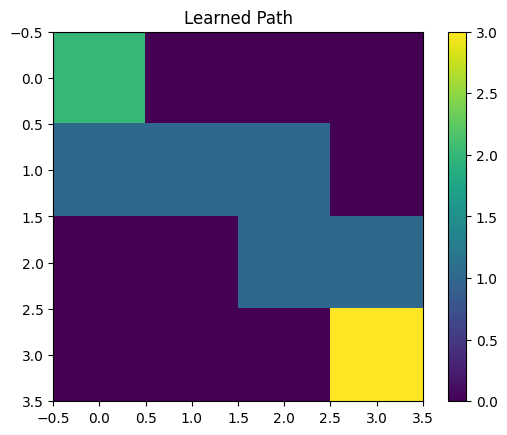

In [ ]:
#Visualize Path
grid = np.zeros((GRID_SIZE, GRID_SIZE))

for r,c in path:
    grid[r][c] = 1

grid[START] = 2
grid[GOAL] = 3

plt.imshow(grid, cmap='viridis')
plt.title("Learned Path")
plt.colorbar()
plt.show()